In [1]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)

/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-12 13:02:47.277948: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-12 13:02:47.278250: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors fro

In [2]:
def lR_to_l(adata, mapper={'leiden_R': 'leiden'}):
    for current_col_name in mapper:
        new_col_name = mapper[current_col_name]
        current_col = adata.obs[current_col_name].copy()
        adata.obs.drop(columns=current_col_name)
        adata.obs[new_col_name] = current_col
    return

def reset_colors(adata, key='leiden', use_plt=True):
    if use_plt:
        try:
            del(adata.uns['plt']['color'][key])
        except:
            pass
    else:
        try:
            del(adata.uns['%s_colors' % key])
        except:
            pass
    return

def relabel_clusts(adata, key='leiden'):
    try:
        adata.obs[key].cat
    except AttributeError:
        adata.obs[key] = adata.obs[key].astype('category')
        
    cats = adata.obs[key].cat.categories
    new_cats = [str(i) for i in range(len(cats))]
    adata.obs[key] = adata.obs[key].map(dict(zip(cats, new_cats)))
    adata.obs[key] = adata.obs[key].astype('category')
    
    reset_colors(adata, key=key)
    
    return

def clean_leiden(adata):
    lR_to_l(adata)
    relabel_clusts(adata)

In [3]:
adata_ori = sc.read_h5ad("E4S_cluster_annotated.h5ad")


In [11]:
adata_ori.obs['cluster_annotation'] = adata_ori.obs['cluster_annotation'].cat.rename_categories({'Malign Epithelial': 'Cancer'})

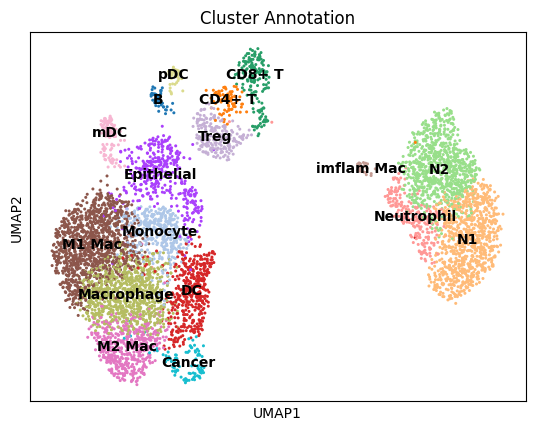

In [12]:
sc.pl.umap(adata_ori, color='cluster_annotation', legend_loc='on data', title='Cluster Annotation', legend_fontsize=10)

In [13]:
adata = adata_ori.copy()
adata = adata[adata.obs['cluster_annotation'].isin(["CD8+ T", "Treg", "CD4+ T"])]

In [14]:
adata


View of AnnData object with n_obs × n_vars = 448 × 2499
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'leiden', 'Macrophage_score', 'T_cell_score', 'Neutrophil_score', 'Dendritic_cell_score', 'Monocyte_score', 'B_cell_score', 'cell_type', 'leiden_R', 'cluster_annotation', 'cnv_leiden', 'cnv_score', 'cnv_status'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'chromosome', 'start', 'end'
    uns: 'cell_type_colors', 'cluster_annotation_colors', 'cnv', 'cnv_leiden', 'cnv_leiden_colors', 'cnv_neighbors', 'cnv_status_colors', 'hvg', 'leiden', 'leiden_R', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'scrublet', 'umap'
    obsm: 'X_cnv', 'X_cnv_pca', 'X_cnv_umap', 'X_pca', 'X_umap'
    varm

In [15]:
adata.obs['cluster_annotation'].value_counts()

cluster_annotation
Treg      202
CD8+ T    168
CD4+ T     78
Name: count, dtype: int64

In [16]:
sc.pp.pca(adata, svd_solver="arpack", n_comps=10, random_state=0)
sc.pp.neighbors(adata, n_neighbors=10, random_state=0)
sc.tl.umap(adata, min_dist=0.2, spread=1, random_state=0)

sc.tl.leiden(adata, resolution=0.6, n_iterations=-1, flavor='igraph', random_state=0)


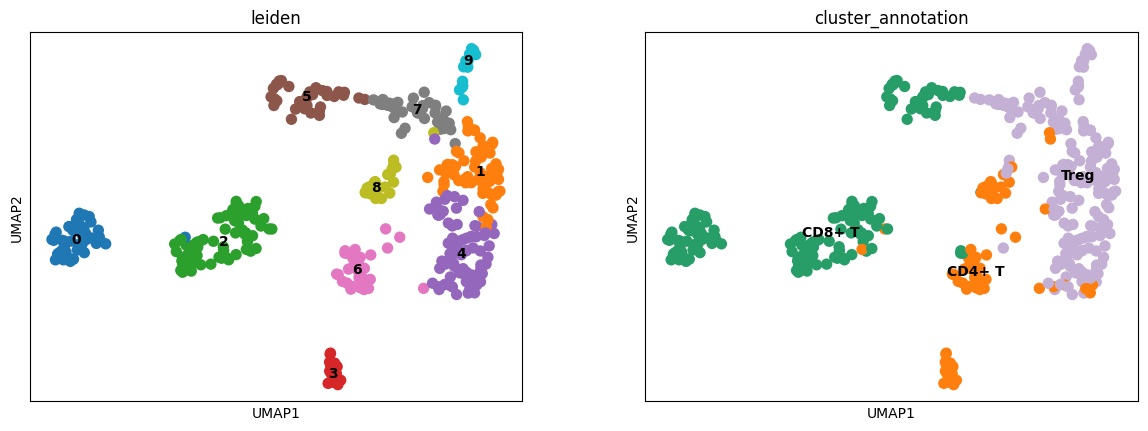

In [17]:
sc.pl.umap(adata, color=["leiden", "cluster_annotation"], legend_loc="on data")

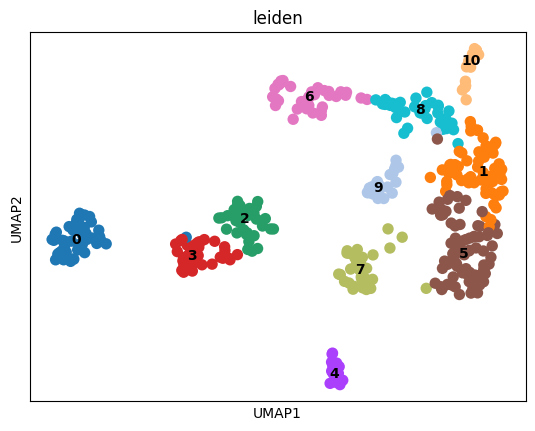

In [18]:
sc.tl.leiden(adata, resolution=0.2, restrict_to=('leiden', ['2']), flavor="igraph", random_state=42)
clean_leiden(adata)
sc.pl.umap(adata, color="leiden", legend_loc="on data")

In [36]:
marker_dict_ref = {
    'CD4+ T': ['Cd4'],
    'CD8+ T': ['Cd8a','Cd8b1', 'Nkg7'],
    'Treg': ['Foxp3', 'Il2ra'] ,
    'gamma': ['Trdc', 'Trgc', 'Trdv']}

umap_params = {
    'legend_loc': "on data",
    's': 30,
    'add_outline': False,
    'ncols': 3,
    'frameon': False
}

UMAP: CD4+ T (markers: ['Cd4'])


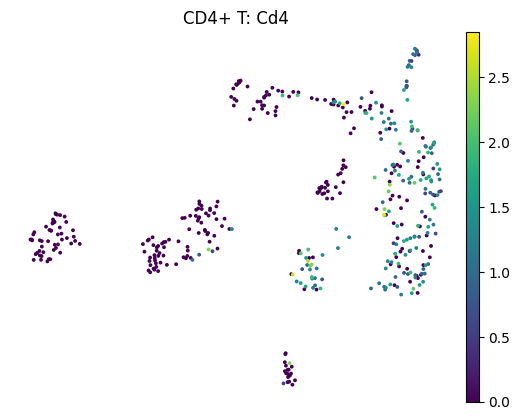

UMAP: CD8+ T (markers: ['Cd8a', 'Cd8b1', 'Nkg7'])


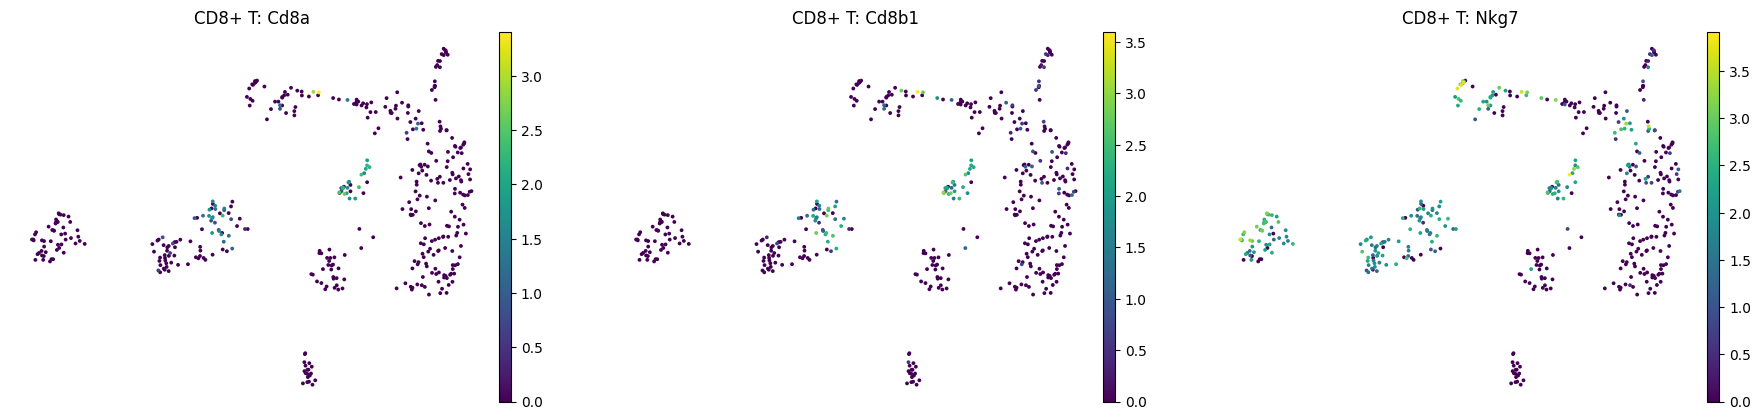

UMAP: Treg (markers: ['Foxp3', 'Il2ra'])


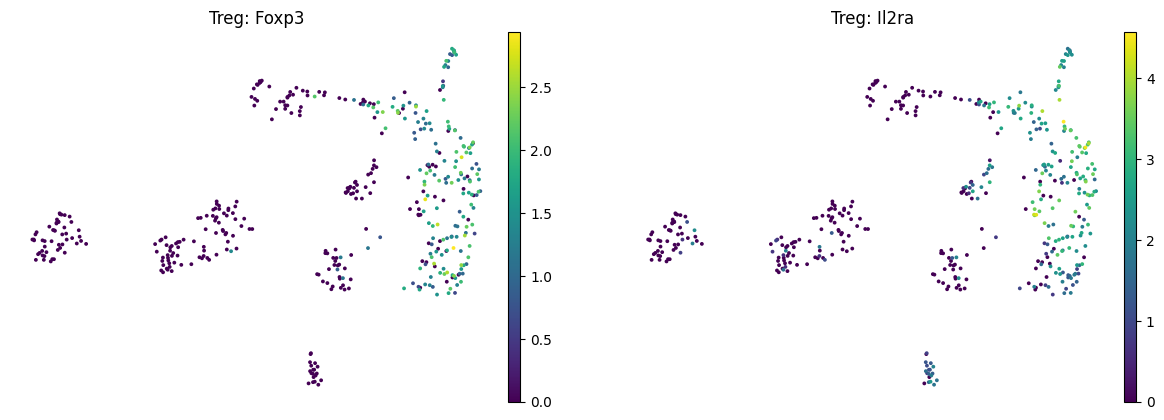

UMAP: gamma (markers: ['Trdc'])


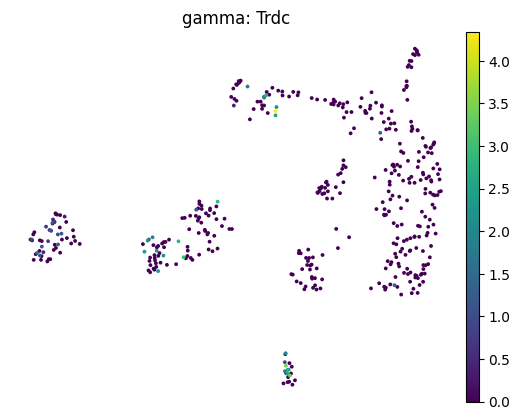

In [37]:
# Plot UMAP for each marker group in marker_dict_ref
for celltype, marker_list in marker_dict_ref.items():
    # Make sure markers exist in your adata.var_names (may want to filter missing ones)
    valid_markers = [gene for gene in marker_list if gene in adata.var_names]
    if not valid_markers:
        print(f"[Warning] No valid markers for {celltype}")
        continue
    print(f"UMAP: {celltype} (markers: {valid_markers})")
    sc.pl.umap(adata, color=valid_markers, title=[f"{celltype}: {gene}" for gene in valid_markers], **umap_params)

In [38]:
state_marker = { 'Memory/Progenitor': ['Tcf7', 'Il7r', 'Ccr7'],
            'Exhaustion': ['Lag3', 'Havcr2', 'Ctla4', 'Pdcd1', 'Tox'],
            'Effector': ['Prf1', 'Gzmb', 'Ifng'],
            'Proliferation': ['Mki67', 'Gins2', 'Mcm5', 'Top2a']}

UMAP: Memory/Progenitor (markers: ['Tcf7', 'Il7r', 'Ccr7'])


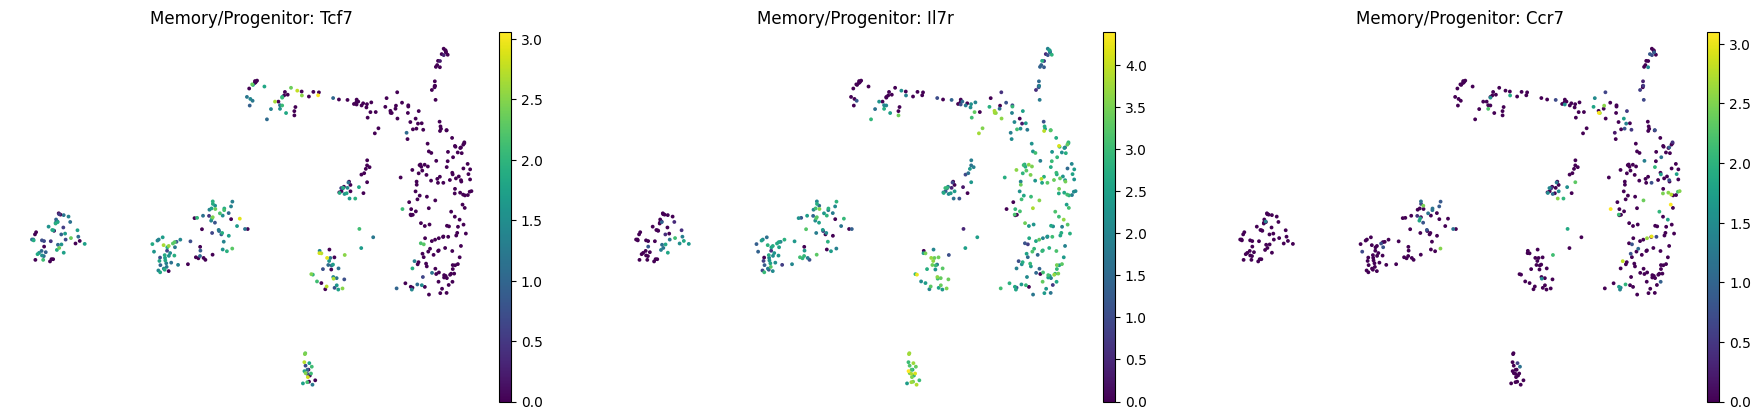

UMAP: Exhaustion (markers: ['Ctla4', 'Pdcd1', 'Tox'])


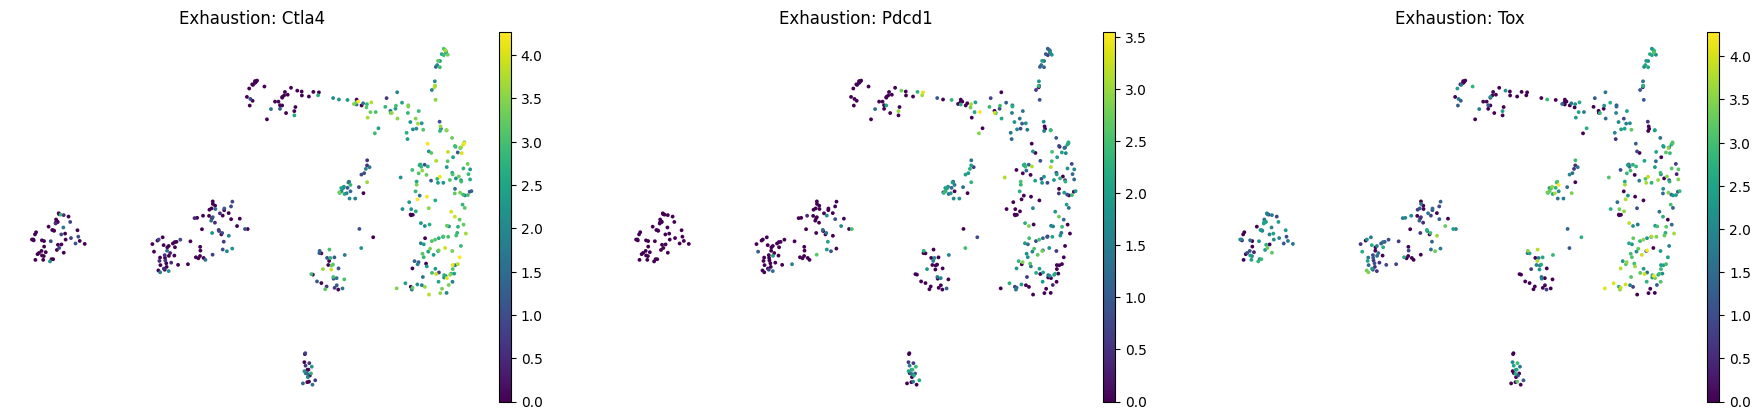

UMAP: Effector (markers: ['Prf1', 'Gzmb', 'Ifng'])


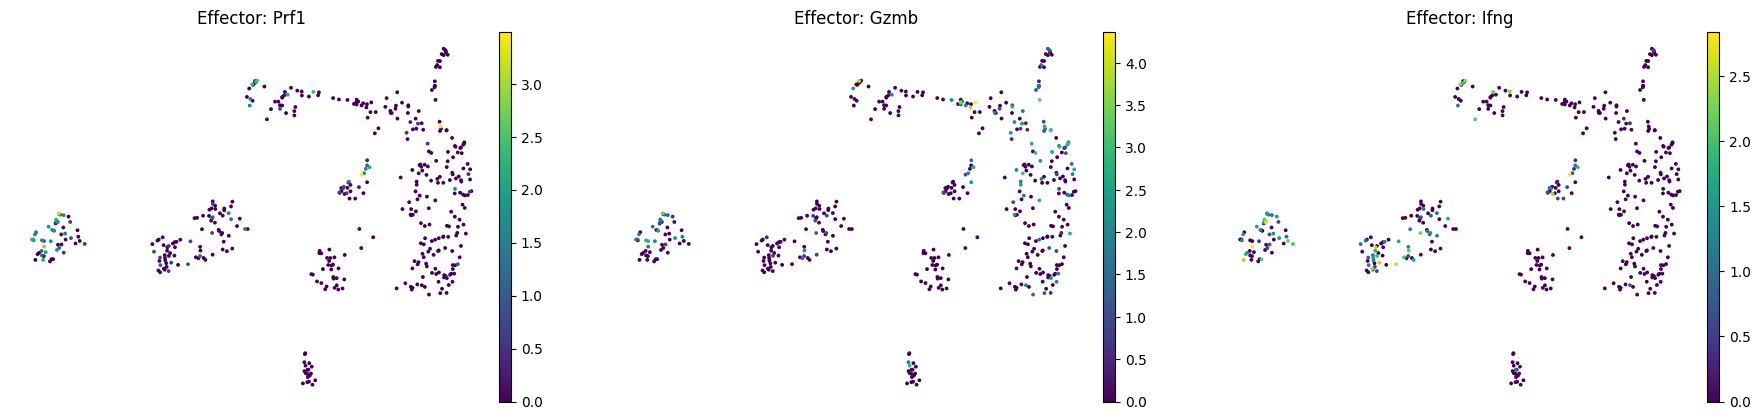

UMAP: Proliferation (markers: ['Mki67', 'Top2a'])


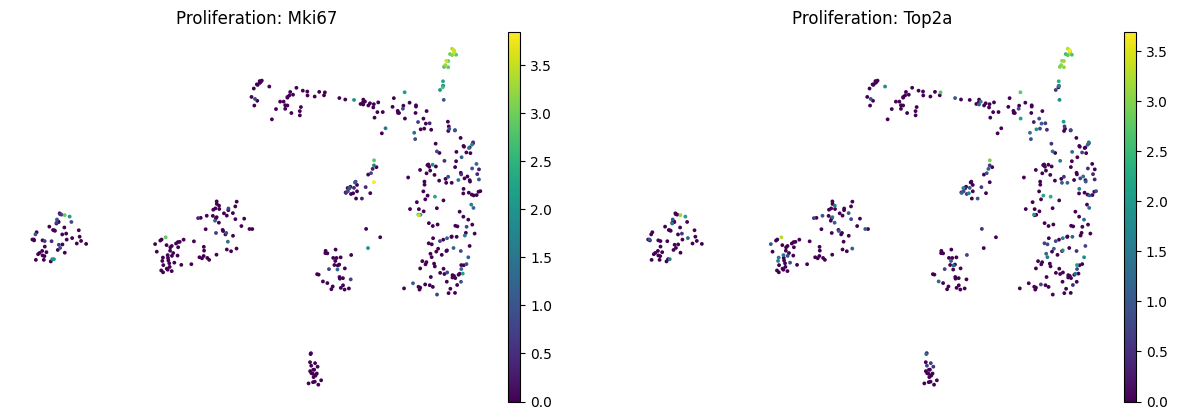

In [39]:
# Plot UMAP for each marker group in marker_dict_ref
for celltype, marker_list in state_marker.items():
    # Make sure markers exist in your adata.var_names (may want to filter missing ones)
    valid_markers = [gene for gene in marker_list if gene in adata.var_names]
    if not valid_markers:
        print(f"[Warning] No valid markers for {celltype}")
        continue
    print(f"UMAP: {celltype} (markers: {valid_markers})")
    sc.pl.umap(adata, color=valid_markers, title=[f"{celltype}: {gene}" for gene in valid_markers], **umap_params)

In [40]:
# Assign preliminary cluster annotation based on mapping
adata.obs['cluster_annotation'] = 'NA'
adata.obs['cluster_annotation'] = adata.obs['cluster_annotation'].astype('category')

In [41]:
cluster_annotation = {
    0: "NKT",

    2: "CD8_mem",
    9: "CD8_mem",
    7: "CD4",
    
    1: "Treg_exh",
    5: "Treg_exh",
    8: "Treg_exh",
    10: "Treg_prolif",

}

... storing 'cluster_annotation' as categorical


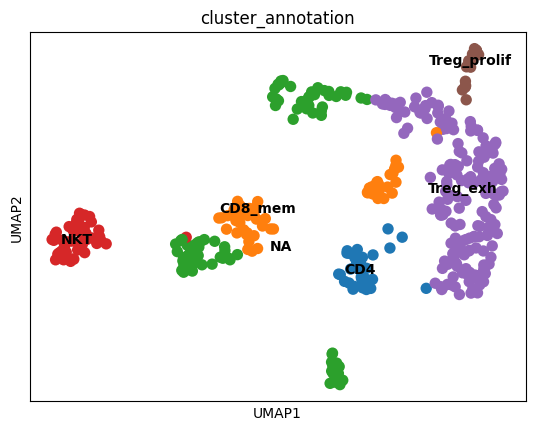

In [42]:
adata.obs['cluster_annotation'] = adata.obs.apply(
    lambda row: cluster_annotation.get(int(row['leiden']), 'NA'),  # Changed default to 'NA'
    axis=1
)
sc.pl.umap(adata, color='cluster_annotation', legend_loc='on data', legend_fontsize=10)

# Decoupler cell type validation

In [43]:
# Cell type validation with decoupler (PanglaoDB markers + ORA)
import decoupler as dc
import numpy as np

# Ensure we have a log-normalized layer for enrichment (decoupler uses expressed genes per cell)
if 'log_norm' not in adata.layers:
    adata.layers['log_norm'] = adata.X.copy()

# Load PanglaoDB cell type markers (mouse – matches Cd4, Cd8a, etc.)
markers = dc.op.resource(name='PanglaoDB', organism='mouse', license='academic')
markers = markers[markers['canonical_marker'].astype(bool) & markers['mouse'].astype(bool)]
markers = markers[~markers.duplicated(['cell_type', 'genesymbol'])]
# Focus on immune/T cell–relevant types
t_related = ['T cells', 'T cells naive', 'T memory cells', 'NK cells', 'NKT cells', 'Gamma delta T cells',
             'Cytotoxic T cells', 'Regulatory T cells', 'T helper cells']
available = [c for c in t_related if c in markers['cell_type'].values]
if available:
    markers = markers[markers['cell_type'].isin(available)]

markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]



In [44]:
# Run ulm: enrichment of cell-type marker sets per cell
dc.mt.ulm(
    data=adata, net=markers, tmin=3
)

In [45]:

adata.obsm["score_ulm"]

,Gamma delta T cells,NK cells,T cells,T helper cells
AAACGTCCAATATCAG-1,0.884619,7.904197,6.130894,2.526693
AAACTCCGTAAGTACG-1,-1.105056,1.335411,7.323618,2.598717
AACACACCAATACTGA-1,1.966717,5.098830,9.063440,2.489551
AACACATTCACCTAAG-1,-0.309253,1.485670,8.489789,1.543245
AACACCATCATCACGA-1,2.601891,8.404583,8.254525,1.697824
...,...,...,...,...
TGTATTCCATAAGCTA-1,2.590909,6.784277,5.162584,2.039254
TGTCATTCAATCGCTC-1,6.478651,10.201608,5.226564,0.957564
TGTCGAATCTGGCCTC-1,0.389396,1.447524,6.031605,0.216522
TGTCGAATCTGGGACT-1,0.944581,2.135952,7.931409,3.392098


In [46]:
score = dc.pp.get_obsm(adata, key="score_ulm")

# GSEA

In [47]:
# CD8 vs CD4/Treg using cluster_annotation

import os
import numpy as np
import pandas as pd
import gseapy as gp

# 1) Define groups from cluster_annotation
annot = adata.obs['cluster_annotation'].astype(str)
mask = annot != 'NA'
adata_gsea = adata[mask].copy()

adata_gsea.obs['broad_type'] = 'CD4_Treg'
adata_gsea.obs.loc[adata_gsea.obs['cluster_annotation'].str.contains('CD8', na=False), 'broad_type'] = 'CD8'
adata_gsea.obs['broad_type'] = adata_gsea.obs['broad_type'].astype('category')

print('Cells per broad_type:')
print(adata_gsea.obs['broad_type'].value_counts())

# 2) Ranked gene lists via scanpy (each group vs rest)
# Use log-normalized data; if adata is raw counts, run: sc.pp.log1p(adata_gsea)
if not hasattr(adata_gsea.X, 'max') or adata_gsea.X.max() > 30:
    sc.pp.log1p(adata_gsea)

sc.tl.rank_genes_groups(
    adata_gsea,
    groupby='broad_type',
    method='t-test',
    n_genes=adata_gsea.n_vars,
)

# Extract ranked list per group: gene -> log2 fold-change (sorted high to low)
rg = adata_gsea.uns['rank_genes_groups']
ranked_per_group = {}
for g in rg['names'].dtype.names:
    names = pd.Series(rg['names'][g])
    lfc = pd.Series(rg['logfoldchanges'][g])
    s = pd.Series(lfc.values, index=names.values)
    s = s[~s.index.duplicated(keep='first')].sort_values(ascending=False)
    ranked_per_group[g] = s

if not ranked_per_group:
    print('No groups with enough cells for GSEA.')


Cells per broad_type:
broad_type
CD4_Treg    286
CD8          63
Name: count, dtype: int64


In [48]:
# 3) Gene set library 
gobp = gp.get_library('GO_Biological_Process_2023')  # adjust name from step 1

immune_keywords = [
    # T cell specific
    'T cell', 'T-cell',
    'CD4', 'CD8', 'regulatory T', 'helper T', 'cytotoxic',
    
    # General immune
    'immune', 'immunity', 'immunolog',
    
    # Killing/activation
    'apoptosis', 'cytotoxicity', 'killing',
    'activation', 'proliferation','exhaustion', 'effector', 'memory T',
]

filtered_gobp = {
    k: v for k, v in gobp.items()
    if any(kw.lower() in k.lower() for kw in immune_keywords)
}
print(f'filtered_gobp: {len(filtered_gobp)} immune-related GO BP sets')



2026-03-12 13:22:52 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-12 13:22:58 | [INFO] 0001 gene_sets have been filtered out when max_size=2000 and min_size=0


filtered_gobp: 349 immune-related GO BP sets


In [49]:
# 4) Run preranked GSEA per group and per library
outdir = 'gsea_CD4_CD8_clean'
os.makedirs(outdir, exist_ok=True)

gsea_results = {}
summary_tables = []

# Run GSEA with immune-filtered GO BP (filtered_gobp)
lib = 'GO_BP_immune'
gene_sets_for_gseapy = {k: v for k, v in filtered_gobp.items() if len(v) >= 5 and len(v) <= 5000}
if gene_sets_for_gseapy:
    print(f'Library: {lib} ({len(gene_sets_for_gseapy)} sets)')
    for g, rnk in ranked_per_group.items():
        rnk_up = rnk.copy()
        rnk_up.index = rnk_up.index.str.upper()
        rnk_up = rnk_up[~rnk_up.index.duplicated(keep='first')]
        subdir = f'prerank_{g}_{lib}'
        pre_res = gp.prerank(
            rnk=rnk_up,
            gene_sets=gene_sets_for_gseapy,
            min_size=5,
            max_size=5000,
            processes=4,
            permutation_num=1000,
            outdir=os.path.join(outdir, subdir),
            seed=0,
            verbose=True,
        )
        gsea_results[(lib, g)] = pre_res
        df = pre_res.res2d.copy()
        if 'Term' in df.columns:
            df['Term'] = df['Term'].astype(str).str.replace(r'\(GO:[^)]+\)', '', regex=True).str.strip()
        df['group'] = g
        df['library'] = lib
        summary_tables.append(df)
else:
    print(f'Library: {lib} — no sets after size filter, skipping.')


# Save each (library, group) result as a separate CSV
for (lib, g), pre_res in gsea_results.items():
    safe_lib = lib.replace(' ', '_').replace('/', '_')[:50]
    path = os.path.join(outdir, f'gsea_{safe_lib}_{g}.csv')
    out_df = pre_res.res2d.copy()
    if 'Term' in out_df.columns:
        out_df['Term'] = out_df['Term'].astype(str).str.replace(r'\(GO:[^)]+\)', '', regex=True).str.strip()
    out_df.to_csv(path, index=False)
if gsea_results:
    print(f'Saved {len(gsea_results)} separate CSV(s) to {outdir}')
else:
    print('No GSEA results collected.')


2026-03-12 13:22:58,967 [WARNING] Duplicated values found in preranked stats: 10.36% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-12 13:22:58,967 [INFO] Parsing data files for GSEA.............................
2026-03-12 13:22:58,970 [INFO] 0203 gene_sets have been filtered out when max_size=5000 and min_size=5
2026-03-12 13:22:58,971 [INFO] 0146 gene_sets used for further statistical testing.....
2026-03-12 13:22:58,971 [INFO] Start to run GSEA...Might take a while..................


Library: GO_BP_immune (349 sets)


2026-03-12 13:23:00 | [INFO] maxp pruned
2026-03-12 13:23:00 | [INFO] cmap pruned
2026-03-12 13:23:00 | [INFO] kern dropped
2026-03-12 13:23:00 | [INFO] post pruned
2026-03-12 13:23:00 | [INFO] FFTM dropped
2026-03-12 13:23:00 | [INFO] GPOS pruned
2026-03-12 13:23:00 | [INFO] GSUB pruned
2026-03-12 13:23:00 | [INFO] glyf pruned
2026-03-12 13:23:00 | [INFO] Added gid0 to subset
2026-03-12 13:23:00 | [INFO] Added first four glyphs to subset
2026-03-12 13:23:00 | [INFO] Closing glyph list over 'GSUB': 34 glyphs before
2026-03-12 13:23:00 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'E', 'G', 'O', 'R', 'S', 'a', 'c', 'colon', 'd', 'e', 'four', 'h', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'r', 'space', 't', 'three', 'two', 'v', 'zero']
2026-03-12 13:23:00 | [INFO] Glyph IDs:   [0, 1, 2, 3, 11, 12, 19, 20, 21, 22, 23, 29, 36, 37, 38, 40, 42, 50, 53, 54, 68, 70, 71, 72, 75, 76, 78, 79, 80, 81, 82, 85, 87, 89]
2026-03-12 13:23:00 | [INFO

Saved 2 separate CSV(s) to gsea_CD4_CD8_clean


In [50]:
pre_res